# Notebook 1 - Reproducing and auditing the original (first-draft) pipeline

This notebook does three things, in this order.

1. Re-runs the **unchanged** first-draft code (`prep.py`, `run_experiments.py`) in a scratch folder and checks that it reproduces the numbers printed in the first draft. That shows the audit below is about the real pipeline and not about a re-implementation.
2. Re-computes the privacy parameters of the first draft with an exact accountant.
3. Quantifies how much of the headline accuracy was a property of one lucky 123-row test split.

Everything here is computed when the notebook runs. Nothing is typed in by hand except the first-draft values we compare against, which are read from the shipped `results.json`.

In [1]:
import os, sys, json, shutil, subprocess, hashlib, platform, tempfile, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, os.path.join(ROOT, 'v2'))
sha = lambda p: hashlib.sha256(open(p, 'rb').read()).hexdigest()[:16]
print('python', platform.python_version(), '| numpy', np.__version__, '| pandas', pd.__version__)
print('git HEAD :', subprocess.run(['git', '-C', ROOT, 'rev-parse', '--short', 'HEAD'], capture_output=True, text=True).stdout.strip())
for f in ['Train.csv', 'prep.py', 'dpmlp.py', 'run_experiments.py', 'results.json']: print(f'{f:22s} sha256[:16] = {sha(os.path.join(ROOT, f))}')

python 3.12.3 | numpy 2.4.4 | pandas 3.0.2
git HEAD : 8a95b30
Train.csv              sha256[:16] = 89d58f5df3388280
prep.py                sha256[:16] = 1c43ef4d2c919974
dpmlp.py               sha256[:16] = f762d4a03a073741
run_experiments.py     sha256[:16] = 179b85ca5c1a600d
results.json           sha256[:16] = 76eccc878b822ec2


## 1. Re-run the first-draft code, unchanged

The scripts are copied to a scratch directory and executed there. The shipped `results.json` is not touched.

In [2]:
scratch = tempfile.mkdtemp()
for f in ['Train.csv', 'prep.py', 'dpmlp.py', 'run_experiments.py']: shutil.copy(os.path.join(ROOT, f), scratch)
for script in ['prep.py', 'run_experiments.py']:
    r = subprocess.run([sys.executable, script], cwd=scratch, capture_output=True, text=True); print(script, 'exit code', r.returncode)
new = json.load(open(os.path.join(scratch, 'results.json'))); old = json.load(open(os.path.join(ROOT, 'results.json')))
def flat(d, p=''):
    for k, v in d.items():
        if isinstance(v, dict): yield from flat(v, p + k + '.')
        elif isinstance(v, (int, float)): yield p + k, v
fo, fn = dict(flat(old)), dict(flat(new)); common = [k for k in fo if k in fn]
diff = max(abs(fo[k] - fn[k]) for k in common)
print(f'{len(common)} numeric entries compared, largest absolute difference = {diff:.2e}')
assert diff < 1e-9, 'first-draft pipeline did not reproduce'

prep.py exit code 0


run_experiments.py exit code 0
67 numeric entries compared, largest absolute difference = 0.00e+00


### What the first draft reported

In [3]:
b = old['baseline_nonprivate']; cvd = old['cv_5fold']
print('Single split (5 seeds)  accuracy %.4f  AUC %.4f' % (b['mean']['accuracy'], b['mean']['roc_auc']))
print('5-fold CV on all data   accuracy %.4f  AUC %.4f' % (cvd['accuracy_mean'], cvd['auc_mean']))
sw = pd.DataFrame([{'sigma': s['sigma'], 'epsilon_reported': s['epsilon'], 'delta_nominal': s['delta'], 'accuracy': s['mean']['accuracy'], 'AUC': s['mean']['roc_auc']} for s in old['dp_sgd_sweep']])
sw

Single split (5 seeds)  accuracy 0.8325  AUC 0.7750
5-fold CV on all data   accuracy 0.8078  AUC 0.6912


,sigma,epsilon_reported,delta_nominal,accuracy,AUC
0,200.0,0.394191,0.002037,0.484553,0.494272
1,100.0,0.810333,0.002037,0.582114,0.535294
2,60.0,1.400420,0.002037,0.679675,0.599257
3,40.0,2.196811,0.002037,0.730081,0.626873
4,25.0,3.804387,0.002037,0.791870,0.712136
5,15.0,7.268777,0.002037,0.819512,0.740062


## 2. Audit A - privacy accounting

The first draft computes epsilon with the advanced-composition theorem and splits delta as `delta0 = delta' = delta/2`. Two things follow from that arithmetic, both checked below:

* the delta that is actually achieved is `k*delta0 + delta'`, which is far larger than the nominal 1/491;
* for 30 full-batch Gaussian steps there is an **exact** accountant: the 30 releases form one Gaussian mechanism with `mu = sqrt(30)/sigma`, so epsilon can be read off the closed form (derivation and Monte-Carlo check are in Notebook 2 and in the paper's appendix).

We use two independent exact accountants: our own closed form and Google's `dp_accounting` PLD accountant. If they agree, the number is not an artefact of one implementation.

In [4]:
from accounting import eps_fullbatch_exact, eps_pld, eps_rdp, eps_advanced_paper
rows = []
for s in old['dp_sgd_sweep']:
    sg = s['sigma']; e_adv, d_act = eps_advanced_paper(sg, 30, 1/491)
    rows.append({'sigma': sg, 'eps first draft': round(s['epsilon'], 3), 'recomputed first-draft formula': round(e_adv, 3), 'delta actually achieved': round(d_act, 4),
                 'exact eps @ delta=1/491': round(eps_fullbatch_exact(sg, 30, 1/491), 3), 'exact eps @ delta=1e-5': round(eps_fullbatch_exact(sg, 30, 1e-5), 3),
                 'PLD eps @ delta=1e-5': round(eps_pld(sg, 30, 1e-5), 3), 'RDP eps @ delta=1e-5': round(eps_rdp(sg, 30, 1e-5), 3)})
acc = pd.DataFrame(rows); acc

,sigma,eps first draft,recomputed first-draft formula,delta actually achieved,exact eps @ delta=1/491,exact eps @ delta=1e-5,PLD eps @ delta=1e-5,RDP eps @ delta=1e-5
0,200.0,0.394,0.394,0.0316,0.029,0.083,0.083,0.093
1,100.0,0.810,0.810,0.0316,0.077,0.177,0.177,0.197
2,60.0,1.400,1.400,0.0316,0.150,0.308,0.308,0.340
3,40.0,2.197,2.197,0.0316,0.251,0.480,0.480,0.527
4,25.0,3.804,3.804,0.0316,0.449,0.802,0.802,0.877
5,15.0,7.269,7.269,0.0316,0.838,1.406,1.406,1.532


In [5]:
assert np.allclose(acc['eps first draft'], acc['recomputed first-draft formula'], atol=2e-3), 'we do not reproduce the first-draft epsilon'
assert np.allclose(acc['exact eps @ delta=1e-5'], acc['PLD eps @ delta=1e-5'], atol=2e-3), 'closed form and PLD disagree'
print('first-draft epsilon reproduced; closed form and PLD agree to 3 decimals')
r1 = acc['eps first draft'] / acc['exact eps @ delta=1/491']; r2 = acc['eps first draft'] / acc['exact eps @ delta=1e-5']
print('Overstatement at the SAME nominal delta (1/491): %.1fx to %.1fx   <- the figure used in the paper' % (r1.min(), r1.max()))
print('Overstatement against the exact eps at the stricter delta=1e-5 used in the paper: %.1fx to %.1fx' % (r2.min(), r2.max()))

first-draft epsilon reproduced; closed form and PLD agree to 3 decimals
Overstatement at the SAME nominal delta (1/491): 8.5x to 13.6x   <- the figure used in the paper
Overstatement against the exact eps at the stricter delta=1e-5 used in the paper: 4.5x to 5.2x


## 3. Audit B - where the leakage is in the code

These are the exact lines of the first-draft scripts (printed from the files, not retyped).

In [6]:
def show(path, needles, width=1):
    L = open(os.path.join(ROOT, path)).read().splitlines()
    for i, line in enumerate(L):
        if any(n in line for n in needles): print(f'{path}:{i+1:>3}: {line.strip()[:150]}')
print('-- imputation / encoding is done on the whole file before any split:')
show('prep.py', ['fillna', 'train_test_split', 'StandardScaler', 'fit_transform'])
print('\n-- the balancing strategy is picked by looking at test-set F1:')
show('run_experiments.py', ['best_key', 'max('])
print('\n-- clipping norm used for DP-SGD:')
show('run_experiments.py', ['clip'])

-- imputation / encoding is done on the whole file before any split:
prep.py:  2: from sklearn.model_selection import train_test_split
prep.py:  3: from sklearn.preprocessing import StandardScaler
prep.py: 13: df[c] = df[c].fillna(df[c].mode()[0])
prep.py: 14: df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mode()[0])
prep.py: 15: df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].median())
prep.py: 16: df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())
prep.py: 48: X_train, X_test, y_train, y_test = train_test_split(
prep.py: 52: scaler = StandardScaler()
prep.py: 53: X_train_s = scaler.fit_transform(X_train)

-- the balancing strategy is picked by looking at test-set F1:
run_experiments.py: 57: best_key = max(results["class_balance_comparison"],
run_experiments.py: 59: print("Best balancing strategy:", best_key)
run_experiments.py: 60: if best_key == "smote":
run_experiments.py: 63: elif best_key == "class_weightin

## 4. Audit C - how much does one 123-row split tell us?

The first draft's single split has 123 test applicants. With an accuracy near 0.83 the binomial standard error alone is about 3.4 percentage points. Below we run the same MLP configuration of the first draft (lr 0.5, 30 epochs) on 25 leak-free train/test splits and see where 0.8325 falls.

In [7]:
n_test, p = 123, old['baseline_nonprivate']['mean']['accuracy']
se = np.sqrt(p * (1 - p) / n_test); print(f'accuracy {p:.4f} on n={n_test}: standard error {100*se:.1f} points, 95% interval roughly [{p-1.96*se:.3f}, {p+1.96*se:.3f}]')
exp1 = json.load(open(os.path.join(ROOT, 'v2', 'results', 'exp1.json')))
accs = np.array([r['models']['mlp_paper_cfg']['acc'] for r in exp1]); aucs = np.array([r['models']['mlp_paper_cfg']['auc'] for r in exp1])
print(f'first-draft MLP configuration, leak-free 5x5 CV: accuracy {accs.mean():.3f} (sd {accs.std(ddof=1):.3f}), AUC {aucs.mean():.3f}')
print(f'share of the 25 splits whose accuracy is >= 0.8325: {np.mean(accs >= 0.8325):.0%}')
print(f'majority-class accuracy {np.mean([r["models"]["majority"]["acc"] for r in exp1]):.3f};  rule "Credit_History == 1 -> approve": {np.mean([r["models"]["credit_history_rule"]["acc"] for r in exp1]):.3f}')

accuracy 0.8325 on n=123: standard error 3.4 points, 95% interval roughly [0.767, 0.899]
first-draft MLP configuration, leak-free 5x5 CV: accuracy 0.799 (sd 0.022), AUC 0.745
share of the 25 splits whose accuracy is >= 0.8325: 12%
majority-class accuracy 0.687;  rule "Credit_History == 1 -> approve": 0.809


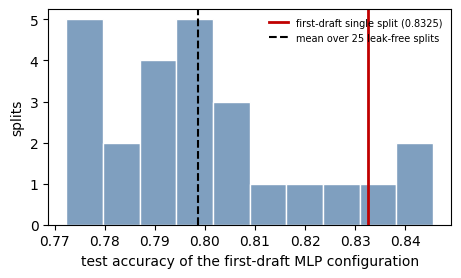

In [8]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5.2, 2.8)); ax.hist(accs, bins=10, color='#7f9fbf', edgecolor='white'); ax.axvline(p, color='#c00000', lw=2, label='first-draft single split (0.8325)')
ax.axvline(accs.mean(), color='k', ls='--', label='mean over 25 leak-free splits'); ax.set_xlabel('test accuracy of the first-draft MLP configuration'); ax.set_ylabel('splits'); ax.legend(fontsize=7, frameon=False); plt.show()

## Summary of what this notebook establishes

* The first-draft pipeline reproduces bit-for-bit from the shipped code and data.
* Its epsilon values are overstated by a large factor relative to two independent exact accountants, and the delta it actually achieves is not the nominal one.
* Imputation, scaling statistics and the balancing strategy were fitted on data that included the test rows.
* A single 123-row split cannot support a claim at the two-decimal level; the leak-free 25-split mean is lower and the single-feature rule is competitive.

The corrected study is in `notebooks/02_corrected_study.ipynb`.